# Final Project

In [23]:
# Import packages 
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

## Problem Definition

A critical challenge for higher education institutions is the rate of student attrition, which negatively impacts institutional reputation, financial stability, and long-term student success. 

By the time a student officially withdraws, it is often too late for the university to intervene. Therefore, the core problem is the inability to identify "at-risk" students early enough in their academic journey. 

The objective is to leverage historical demographic, socioeconomic, and academic data to build a predictive classification model.

By categorizing students as Dropout, Enrolled, or Graduate, the institution can proactively deploy targeted support and resource interventions before the student reaches a point of non-recovery.

## Data Collection 

In [4]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
predict_students_dropout_and_academic_success = fetch_ucirepo(id=697) 

# data (as pandas dataframes) 
df = predict_students_dropout_and_academic_success.data.original

# variable information 
print(predict_students_dropout_and_academic_success.variables) 

                                              name     role         type  \
0                                   Marital Status  Feature      Integer   
1                                 Application mode  Feature      Integer   
2                                Application order  Feature      Integer   
3                                           Course  Feature      Integer   
4                       Daytime/evening attendance  Feature      Integer   
5                           Previous qualification  Feature      Integer   
6                   Previous qualification (grade)  Feature   Continuous   
7                                      Nacionality  Feature      Integer   
8                           Mother's qualification  Feature      Integer   
9                           Father's qualification  Feature      Integer   
10                             Mother's occupation  Feature      Integer   
11                             Father's occupation  Feature      Integer   
12          

## Exploratory Data Analysis 

In [5]:
df.head()

,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [6]:
# Check for missing values 
df.isnull().sum()

Marital Status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance                        0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                                0
Age at enrol

In [7]:
df.describe()

,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


In [8]:
# Check for duplicates
num_duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}")

Number of duplicate rows: 0


/var/folders/7z/mskpp1h52vb0qn4_qsqn6ksw0000gn/T/ipykernel_31896/347557250.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Target', data=df, palette='viridis', order=['Dropout', 'Enrolled', 'Graduate'])


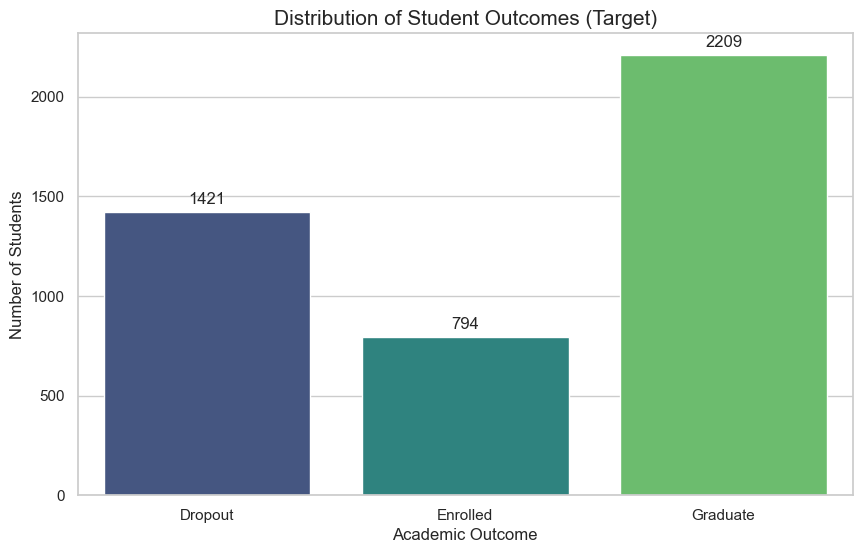

In [9]:
# Check the Target class distribution 
# Set the visual style
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))
ax = sns.countplot(x='Target', data=df, palette='viridis', order=['Dropout', 'Enrolled', 'Graduate'])

# Adding titles and labels
plt.title('Distribution of Student Outcomes (Target)', fontsize=15)
plt.xlabel('Academic Outcome', fontsize=12)
plt.ylabel('Number of Students', fontsize=12)

# Add the count labels on top of each bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')

plt.show()

**Data Imbalance Analysis:**
- Total Students: 4,424
- Graduate (50%): Half of our dataset consists of successfully graduated students.
- Dropout (32%): Roughly one-third of the students have dropped out.
- Enrolled (18%): This is the smallest class and represents students still in the system.

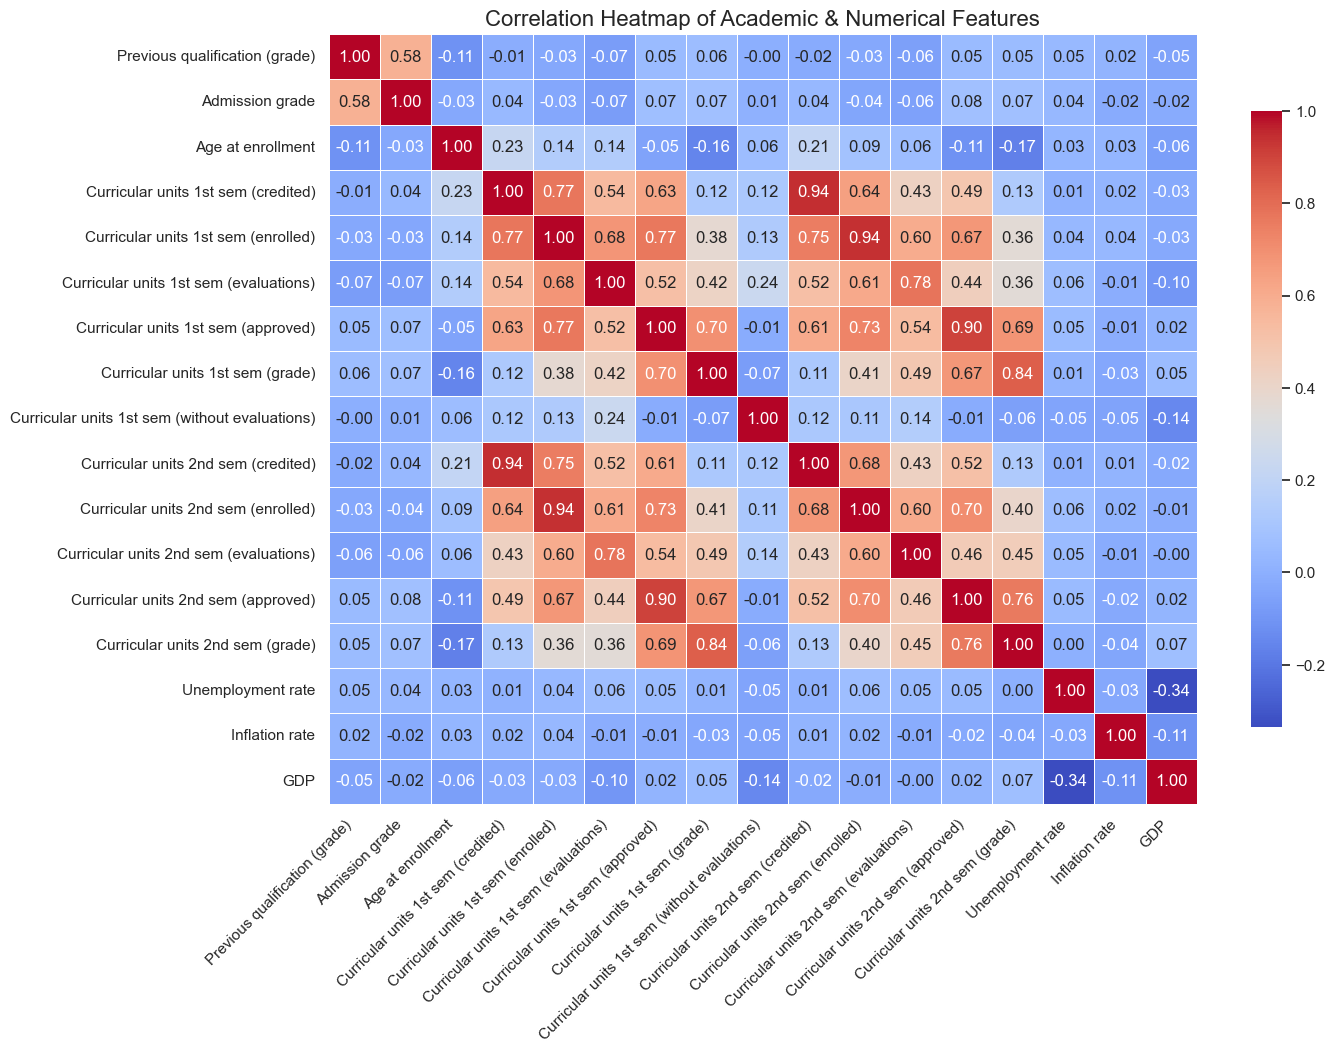

In [10]:
# Generate a correlation heatmap
# Select only numerical/academic columns
numerical_cols = [
    'Previous qualification (grade)', 'Admission grade', 'Age at enrollment',
    'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)',
    'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)',
    'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)', 'Unemployment rate', 'Inflation rate', 'GDP'
]

# Calculate the correlation matrix
corr_matrix = df[numerical_cols].corr()


# Set up the matplotlib figure
plt.figure(figsize=(14, 10))

# Draw the heatmap
heatmap = sns.heatmap(
    corr_matrix, 
    annot=True,          # Show the numbers
    fmt=".2f",           # 2 decimal places
    cmap='coolwarm',     # Red for positive, blue for negative corr
    linewidths=0.5, 
    cbar_kws={"shrink": .8}
)

plt.title('Correlation Heatmap of Academic & Numerical Features', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.show()

**Analysis:**
1) There is a high correlation (0.84) between 1st and 2nd semester grades.
2) The Previous qualification (grade) shows low correlation with university grades. It shows that how a student performed in high school is a poor predictor of how they will do in university. 
3) The macroeconomic variables (unemployment rate, inflation rate, GDP) show very low correlation with the academic variables. This suggests that while economic factors might influence the decision to drop out, they don't necessarily change how well a student performs in their classes.
4) There is extreme correlation (often > 0.90) between corresponding 1st and 2nd semester features:
    - Curricular units 1st sem vs. 2nd sem (approved): Correlation of 0.90.
    - Curricular units 1st sem vs. 2nd sem (enrolled): Correlation of 0.94.
    - Curricular units 1st sem vs. 2nd sem (credited): Correlation of 0.94.

## Chosing the model 

- I selected XGBoost (Gradient Boosted Decision Trees) because it is the industry standard for structured tabular data. 
- It effectively handles the non-linear relationships between socioeconomic factors and academic success.
- It also has built-in mechanisms to handle the slight class imbalance 
- It provides high accuracy and a "Feature Importance" plot, which tells the university exactly which variables are the strongest predictors of dropout.

## Data Preprocessing 

- From our EDA, there is no missing values and duplicated rows.
- All of our binary variable are correctly encoded as 0 and 1. 
- XGBoost is a tree-based model. We don't need to scale our numeric variables. 

### 1. Label encoding
Since our Target variable is a string, ML algorithm requires the target to be numerical. 

In [11]:
# Label encoding 
le = LabelEncoder()
df['Target'] = le.fit_transform(df['Target'])

#Sanity check 
df['Target'].head()

0    0
1    2
2    0
3    2
4    2
Name: Target, dtype: int64

### 2. Handling categorical variables

There are several columns in this dataset encoded as integers that are actually nominal categorical variables.

For example, the Course column contains ID numbers (e.g., 33, 171, 9238) representing different degrees like "Social Service," "Design," or "Agronomy." 

We must handling them carefully because we don't want the model to think that Course 9238 is "mathematically greater" than Course 33, which is a logical error.

In [12]:
# List of all nominal columns
nominal_cols = [
    'Marital Status', 'Application mode', 'Course', 
    'Nacionality', "Mother's qualification", "Father's qualification", 
    "Mother's occupation", "Father's occupation"
]

# XGBoost Categorical Type
for col in nominal_cols:
    df[col] = df[col].astype('category')

### 3. Split the data 

Using stratify=y is crucial here because of the class imbalance we saw earlier. It ensures the 80/20 split has the same ratio of Dropouts/Graduates in both sets.

In [13]:
X = df.drop('Target', axis=1) # Features
y = df['Target']              # Target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Model Building

In [15]:
model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    objective='multi:softprob',  # objective='multi:softprob' is used for multiclass classification
    tree_method="hist",          # Required for categorical support
    enable_categorical=True,   
    random_state=42
)

model.fit(X_train, y_train)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


## Model Evaluation

### 1. Features Importance
The chart below show which features has the most influence on the target variable. 

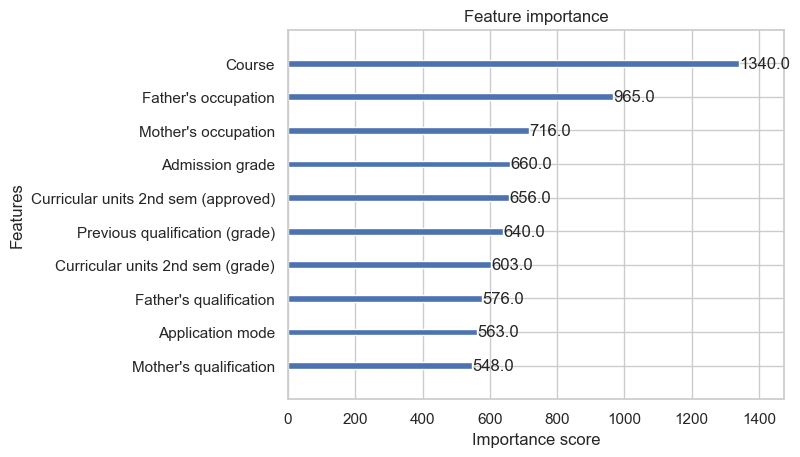

In [26]:
from xgboost import plot_importance
plot_importance(model, max_num_features=10)
plt.show()

**Analysis:**
- Course is the most important feature meaning student success is highly dependent on what they are studying. Some courses may have much higher difficulty levels, more rigorous grading, or different social support structures.
- Four of the top 10 features relate to the student's parents meaning a student's family background is a massive predictor of their academic persistence. 

### 2. Model Accuracy

In [28]:
# Get predictions
y_pred = model.predict(X_test)
# Print Accuracy and Detailed Report
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nDetailed Performance Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Overall Accuracy: 0.7593

Detailed Performance Report:
              precision    recall  f1-score   support

     Dropout       0.77      0.72      0.74       284
    Enrolled       0.52      0.43      0.47       159
    Graduate       0.82      0.90      0.86       442

    accuracy                           0.76       885
   macro avg       0.70      0.68      0.69       885
weighted avg       0.75      0.76      0.75       885



**Analysis:**
- An Overall Accuracy of 0.76 is a good starting point.
- Recall for Dropout is 0.72: we are correctly flagging 72 out of every 100 dropouts.
- A recall of 0.43 for enrolled student is quite low. The model is struggling to distinguish students who are "still enrolled" from those who will eventually graduate or drop out. This category is considered secondary to the primary business objective.
- Since the focus of this Early Warning System is the proactive identification of attrition, the model’s performance in the Dropout category remains the critical metric for success.

### 3. Confusion Matrix 

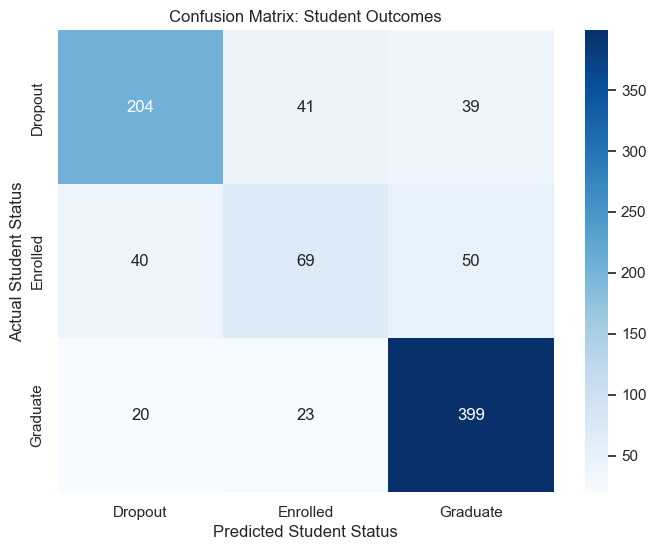

In [24]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix: Student Outcomes')
plt.ylabel('Actual Student Status')
plt.xlabel('Predicted Student Status')
plt.show()